In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [4]:
df = pd.read_csv('data/raw_master_dataset.csv')
print("Read raw master csv success")
display(df.head(5))
display(df.info())
display(df.describe())
display(df['year'].unique().tolist())
print('='*60)
print(f'Data time {df["year"].unique().min()} - {df["year"].unique().max()}')
print(f'Data shape {df.shape}')
print(f'Data size {df.size}')
print(f'Missing value {df[df.isnull().any(axis=1)].size} (~{(df[df.isnull().any(axis=1)].size / df.size):.2f}%)')
print(f'Total Country {df["country"].nunique()}')
print('='*60)


Read raw master csv success


,country_code,country,year,co2_per_capita,co2,ef_per_capita,cropLand,grazingLand,forestLand,fishingGround,...,URB,FDI,GDP,NTR,PO,TO,IND,INF,PS,ED
0,ABW,Aruba,2010,25.030,2.506,NaN,NaN,NaN,NaN,NaN,...,64.161297,7.611672,25429.218097,0.003870,101838.0,135.464655,11.546062,-1.223407,1.256067,0.0014
1,ABW,Aruba,2011,24.706,2.495,NaN,NaN,NaN,NaN,NaN,...,63.999261,18.505780,26093.054208,0.003810,102591.0,154.437787,12.366448,4.005674,1.251139,0.0014
2,ABW,Aruba,2012,13.212,1.345,NaN,NaN,NaN,NaN,NaN,...,63.825209,-12.033180,25444.733665,0.003408,104110.0,156.645197,10.076063,0.184033,1.315909,0.0014
3,ABW,Aruba,2013,8.395,0.861,NaN,NaN,NaN,NaN,NaN,...,63.638291,9.974457,26680.141121,0.002452,105675.0,155.731905,10.749665,-1.995948,1.314319,0.0014
4,ABW,Aruba,2014,8.435,0.872,NaN,NaN,NaN,NaN,NaN,...,63.439253,7.465255,26773.822910,0.003235,106807.0,156.491053,10.799498,0.871011,1.210548,0.0014


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4926 entries, 0 to 4925
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_code    4386 non-null   object 
 1   country         3825 non-null   object 
 2   year            4926 non-null   int64  
 3   co2_per_capita  3480 non-null   float64
 4   co2             3720 non-null   float64
 5   ef_per_capita   1774 non-null   float64
 6   cropLand        1134 non-null   float64
 7   grazingLand     1134 non-null   float64
 8   forestLand      1134 non-null   float64
 9   fishingGround   1134 non-null   float64
 10  builtupLand     1134 non-null   float64
 11  carbon          1134 non-null   float64
 12  BANK            2702 non-null   float64
 13  ATM             2670 non-null   float64
 14  DEP             2618 non-null   float64
 15  LOAN            2622 non-null   float64
 16  FT_Mobile       3635 non-null   float64
 17  FT_Broadband    3540 non-null   f

None

,year,co2_per_capita,co2,ef_per_capita,cropLand,grazingLand,forestLand,fishingGround,builtupLand,carbon,...,URB,FDI,GDP,NTR,PO,TO,IND,INF,PS,ED
count,4926.000000,3480.000000,3720.000000,1774.000000,1134.000000,1134.000000,1134.000000,1134.000000,1134.000000,1134.000000,...,4160.000000,3687.000000,3996.000000,3007.000000,4.160000e+03,3465.000000,3837.000000,4000.000000,3087.000000,3672.000000
mean,2017.423873,4.972782,932.062517,3.058113,0.578857,0.298482,0.470448,0.118990,0.085300,1.573888,...,60.036095,7.370909,15555.858394,6.042942,2.836733e+08,86.844179,26.066983,69.801259,-0.011522,161.450245
std,4.570907,5.843551,3676.396442,2.345742,0.333373,0.501881,0.526134,0.148525,0.054776,1.656217,...,22.622741,58.935809,22535.063160,9.047058,9.426432e+08,55.305069,11.537434,3584.761571,0.988212,508.361268
min,2010.000000,0.022000,0.000000,0.272142,0.078431,0.003512,0.011397,0.000412,0.004143,0.026320,...,10.984310,-1303.108267,253.308578,0.000000,9.492000e+03,0.000000,0.000000,-42.918604,-3.016512,0.000000
25%,2013.000000,0.977750,1.693750,1.262896,0.322942,0.082232,0.174999,0.028720,0.039431,0.251624,...,41.733696,1.222373,2108.270825,0.261915,1.502597e+06,52.022995,18.608987,1.550035,-0.650647,0.572950
50%,2017.000000,3.360000,13.419500,2.386854,0.499738,0.183519,0.272099,0.072214,0.077855,1.103543,...,60.369000,2.511559,6139.726300,2.201002,1.007072e+07,73.537288,25.039083,3.459072,0.031523,5.282750
75%,2021.000000,6.710750,150.618750,4.256564,0.751530,0.356773,0.572798,0.139832,0.116995,2.467201,...,78.555595,4.625017,18982.361768,7.885171,5.175450e+07,105.130362,31.846858,6.444630,0.842078,39.797300
max,2025.000000,49.152000,38598.578000,17.643144,1.939317,5.067615,3.918504,1.159158,0.277943,12.599307,...,100.000000,1709.827232,247170.103807,79.430949,8.215425e+09,679.232773,78.899528,225652.234994,1.759751,4333.608958


[2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

Data time 2010 - 2025
Data shape (4926, 30)
Data size 147780
Missing value 126390 (~0.86%)
Total Country 254


# Cleaning data 
As you can see total countries is 254 so we need to narrow that number down to 145 countries net zero 

In [5]:
# Danh sách 145 quốc gia Net-Zero (kèm chuẩn hóa tên quốc gia theo chuẩn ISO / World Bank / OWID)
net_zero_countries = [
    "Argentina", "Armenia", "Antigua and Barbuda", "Austria", "Belgium", "Burkina Faso", "Bangladesh", "Belize", "Barbados", "Bhutan", 
    "Central African Republic", "Canada", "Switzerland", "Chile", "China", "Colombia", "Comoros", "Cape Verde", "Costa Rica", "Cyprus", 
    "Czech Republic", "Czechia", "Germany", "Djibouti", "Dominica", "Denmark", "Dominican Republic", "Spain", "Estonia", "Ethiopia", "Finland", 
    "Fiji", "France", "Micronesia", "Micronesia (country)", "Gabon", "United Kingdom", "Gambia", "Greece", "Croatia", "Haiti", "Hungary", 
    "Ireland", "Iceland", "Italy", "Jamaica", "Japan", "Cambodia", "Kiribati", "Saint Kitts and Nevis", "South Korea", "Laos", 
    "Lebanon", "Liberia", "Lesotho", "Lithuania", "Luxembourg", "Latvia", "Monaco", "Mexico", "Marshall Islands", "Mali", 
    "Malta", "Myanmar", "Mozambique", "Mauritania", "Mauritius", "Malawi", "Namibia", "Niger", "Nepal", "Nauru", 
    "New Zealand", "Pakistan", "Peru", "Palau", "Papua New Guinea", "Portugal", "Rwanda", "Solomon Islands", "Sao Tome and Principe", "Suriname", 
    "Slovakia", "Slovenia", "Sweden", "Seychelles", "Togo", "East Timor", "Tonga", "Trinidad and Tobago", "Tuvalu", "Uganda", 
    "Uruguay", "Vanuatu", "Samoa", "Yemen", "South Africa", "Andorra", "United Arab Emirates", "Australia", "Bulgaria", "Bahrain", 
    "Brazil", "Brunei", "Georgia", "Ghana", "Honduras", "Indonesia", "India", "Israel", "Kazakhstan", "Kyrgyzstan", 
    "Kuwait", "Liechtenstein", "Sri Lanka", "Moldova", "Montenegro", "Mongolia", "Malaysia", "Nigeria", "Netherlands", "Oman", 
    "Panama", "Romania", "Russia", "Saudi Arabia", "Sudan", "Thailand", "Tunisia", "Turkey", "Tanzania", "Ukraine", 
    "Uzbekistan", "Venezuela", "Vietnam", "Singapore", "United States", "Poland", "Jordan", "Philippines", 
    "Kenya", "Ecuador", "Iraq", "Zambia", "Iran", "Morocco", "Norway"
]

# Chuẩn hóa tên nước Séc và Micronesia trong DataFrame về tên người dùng nhập
# Lọc danh sách quốc gia Net-Zero
filtered_df = df[df['country'].isin(net_zero_countries)].copy()
# Chuẩn hóa hiển thị tên
filtered_df['country'] = filtered_df['country'].replace({'Czechia': 'Czech Republic', 'Micronesia (country)': 'Micronesia'})

# Lưu ra file master_dataset.csv đã được làm sạch
filtered_df.to_csv('data/master_dataset.csv', index=False, encoding='utf-8')
df = filtered_df

unique_year = df['year'].unique()
missing_cells = df.isnull().sum().sum()
total_cells = df.size
percentage = (missing_cells / total_cells) * 100

print('Save master_dataset.csv clean countries assign NET ZERO')
print(f'Khung thời gian (Time range)      : {unique_year.min()} - {unique_year.max()}')
print(f'Tổng số ô dữ liệu (Total cells)   : {df.size} ô')
print(f'Kích thước tập dữ liệu (Shape)    : {df.shape} [{df.shape[0]} dòng x {df.shape[1]} cột]')
print(f'Tổng số quốc gia Net-Zero         : {df["country"].nunique()}')
print(f'Tổng số ô khuyết (Missing cells)  : {missing_cells} ô (~{percentage:.2f}%)')


Save master_dataset.csv clean countries assign NET ZERO
Khung thời gian (Time range)      : 2010 - 2024
Tổng số ô dữ liệu (Total cells)   : 65700 ô
Kích thước tập dữ liệu (Shape)    : (2190, 30) [2190 dòng x 30 cột]
Tổng số quốc gia Net-Zero         : 145
Tổng số ô khuyết (Missing cells)  : 11227 ô (~17.09%)


## Đánh giá mức độ khuyết

In [6]:
import pandas as pd

df = pd.read_csv('data/master_dataset.csv')
    
missing_col = df.isnull().sum()
missing_col_pct = (missing_col / len(df)) * 100

col_audit = pd.DataFrame(
    {
        'Số dòng khuyết (Missing Rows)': missing_col,
        'Tỷ lệ khuyết (%)': missing_col_pct.round(2)
    }
).sort_values(by='Tỷ lệ khuyết (%)', ascending=False).reset_index()

col_audit = col_audit.rename(columns={'index': 'Tên biến (Variable)'})

print('=== 1. TỶ LỆ KHUYẾT DỮ LIỆU THEO BIẾN SỐ ===')
display(col_audit)

=== 1. TỶ LỆ KHUYẾT DỮ LIỆU THEO BIẾN SỐ ===


,Tên biến (Variable),Số dòng khuyết (Missing Rows),Tỷ lệ khuyết (%)
0,carbon,1254,57.26
1,builtupLand,1254,57.26
2,fishingGround,1254,57.26
3,forestLand,1254,57.26
4,grazingLand,1254,57.26
5,cropLand,1254,57.26
6,ef_per_capita,947,43.24
7,NTR,470,21.46
8,LCE,425,19.41
9,TO,277,12.65


In [7]:
country_audit = (df.groupby('country')
                .apply(lambda group: (group.isnull().sum().sum() / group.size) * 100)
                .round(2)
                .reset_index(name='Tỷ lệ khuyết (%)')
                .sort_values(by="Tỷ lệ khuyết (%)", ascending= False)
)

print('=== TOP 10 QUỐC GIA KHUYẾT NHIỀU DỮ LIỆU NHẤT ===')
country_audit.head(10)

=== TOP 10 QUỐC GIA KHUYẾT NHIỀU DỮ LIỆU NHẤT ===


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22584\3755963218.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: (group.isnull().sum().sum() / group.size) * 100)


,country,Tỷ lệ khuyết (%)
89,Nauru,61.67
82,Monaco,57.56
69,Liechtenstein,53.56
132,Tuvalu,46.22
0,Andorra,43.78
143,Yemen,42.22
98,Palau,37.78
141,Venezuela,37.56
61,Kiribati,35.11
100,Papua New Guinea,34.44


In [8]:
good_countries = country_audit[country_audit['Tỷ lệ khuyết (%)'] < 15]
normal_countries = country_audit[
    (country_audit['Tỷ lệ khuyết (%)'] >= 15) &
    (country_audit['Tỷ lệ khuyết (%)'] <= 40)
]
bad_countries = country_audit[country_audit['Tỷ lệ khuyết (%)'] > 40]

print('=== 3. PHÂN BỔ QUỐC GIA THEO MỨC ĐỘ KHUYẾT ===')
print(
    f'• Nhóm đầy đủ/thiếu nhẹ (< 15% missing)  : {len(good_countries)} quốc gia'
)
print(
    f'• Nhóm thiếu trung bình (15% - 40% missing): {len(normal_countries)} quốc gia'
)
print(
    f'• Nhóm thiếu rất nặng (> 40% missing)    : {len(bad_countries)} quốc gia'
)
print(f'-> Danh sách thiếu rất nặng: {bad_countries["country"].tolist()}')

=== 3. PHÂN BỔ QUỐC GIA THEO MỨC ĐỘ KHUYẾT ===
• Nhóm đầy đủ/thiếu nhẹ (< 15% missing)  : 67 quốc gia
• Nhóm thiếu trung bình (15% - 40% missing): 72 quốc gia
• Nhóm thiếu rất nặng (> 40% missing)    : 6 quốc gia
-> Danh sách thiếu rất nặng: ['Nauru', 'Monaco', 'Liechtenstein', 'Tuvalu', 'Andorra', 'Yemen']


In [9]:
print('=== 4. LOẠI BỎ CÁC QUỐC GIA THIẾU QUÁ NHIỀU DỮ LIỆU < 40 % ===')
print(f'Số lượng biến trước khi loại bỏ: {df.size} biến',)
df = df[~df['country'].isin(bad_countries['country'].tolist())]
print(f'Số lượng biến sau khi loại bỏ: {df.size} biến',)
print(f'Số lượng quốc gia còn lại: {df["country"].nunique()} quốc gia')

=== 4. LOẠI BỎ CÁC QUỐC GIA THIẾU QUÁ NHIỀU DỮ LIỆU < 40 % ===
Số lượng biến trước khi loại bỏ: 65700 biến
Số lượng biến sau khi loại bỏ: 62550 biến
Số lượng quốc gia còn lại: 139 quốc gia


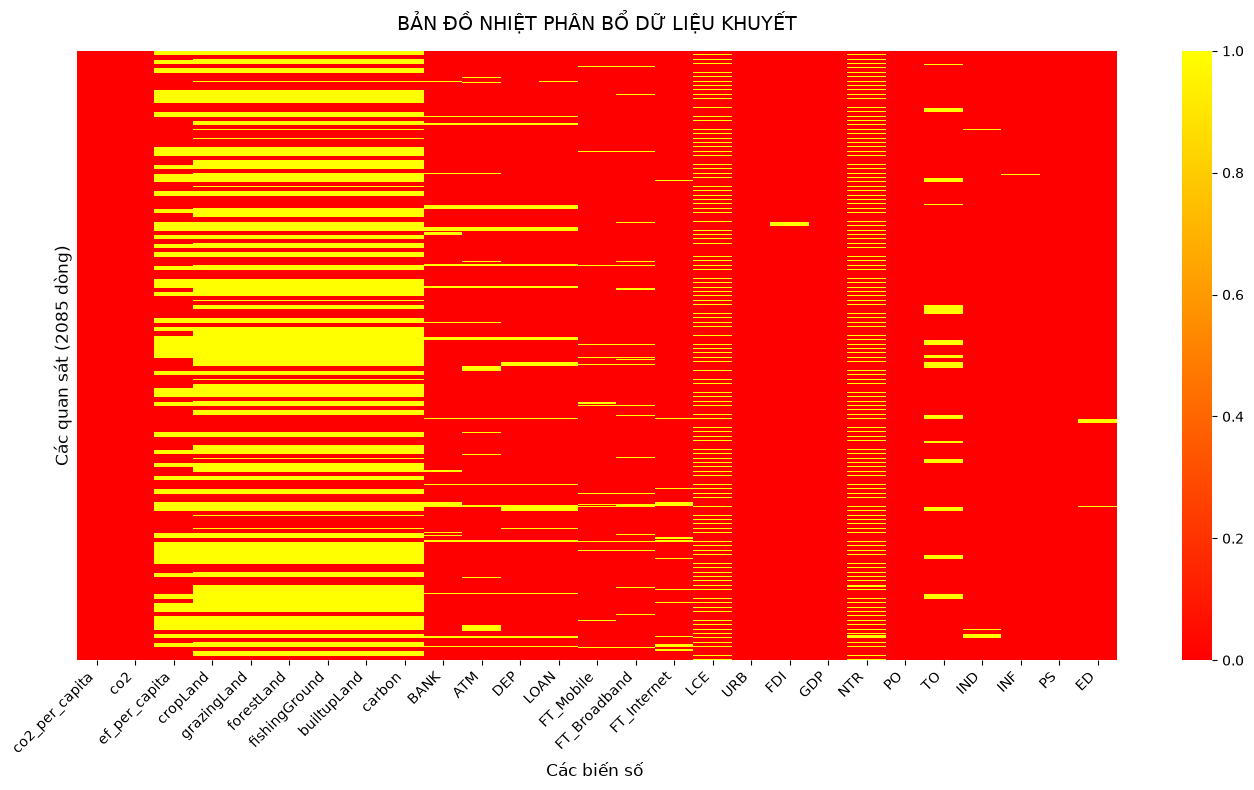

In [10]:
plt.figure(figsize=(14,8))

cols = [c for c in df.columns if c not in ['country_code', 'country', 'year']]

sns.heatmap(df[cols].isnull(), cbar=True, yticklabels=False, cmap='autumn')
plt.title('BẢN ĐỒ NHIỆT PHÂN BỔ DỮ LIỆU KHUYẾT', fontsize = 14, pad = 15)
plt.xlabel('Các biến số ',fontsize = 12 )
plt.ylabel(f'Các quan sát ({df.shape[0]} dòng)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
wb_res = requests.get(
        'https://api.worldbank.org/v2/country?format=json&per_page=400'
    ).json()[1]
iso_map = {
    item['iso2Code']: item['id']
    for item in wb_res
    if item['iso2Code'] and item['id']
}
print(f'Đã tải bảng quy đổi cho {len(iso_map)} quốc gia/vùng lãnh thổ.')

Đã tải bảng quy đổi cho 295 quốc gia/vùng lãnh thổ.


In [12]:
ef_df = pd.read_csv('data/ef_data.csv')

ef_df['country_code'] = ef_df['isoa2'].map(iso_map)

ef_clean = ef_df[['country_code', 'year', 'ef_per_capita', "cropLand", 'grazingLand', 'forestLand' ,'fishingGround' ,'builtupLand' ,'carbon']].dropna(subset=['country_code'])
print('DỮ LIỆU EF SAU KHI CHUYỂN SANG ISO-3')
display(ef_clean.head())

DỮ LIỆU EF SAU KHI CHUYỂN SANG ISO-3


,country_code,year,ef_per_capita,cropLand,grazingLand,forestLand,fishingGround,builtupLand,carbon
0,AFG,2010,0.958796,0.541546,0.209579,0.079680,0.001053,0.025917,0.101021
1,AFG,2011,0.894740,0.456339,0.201633,0.079097,0.000805,0.020081,0.136785
2,AFG,2012,0.917010,0.506302,0.196794,0.074890,0.000540,0.026811,0.111672
3,AFG,2013,0.889364,0.502953,0.188889,0.071154,0.000807,0.027393,0.098169
4,AFG,2014,0.866943,0.488681,0.188572,0.069922,0.000643,0.028166,0.090958


In [13]:
master_df = pd.read_csv('data/master_dataset.csv')

# Nếu master_df đang có ef_per_capita cũ thì xóa đi
if 'ef_per_capita' in master_df.columns:
  master_df = master_df.drop(columns=['ef_per_capita'])

# Chỉ lấy country_code, year và ef_per_capita từ ef_clean để merge vào
ef_subset = ef_clean[['country_code', 'year', 'ef_per_capita']]
master_df = pd.merge(master_df, ef_subset, on=['country_code', 'year'], how='left')

display(master_df.head(5))
master_df.to_csv('data/master_dataset.csv', index=False, encoding='utf-8')

missing_ef = master_df['ef_per_capita'].isnull().sum()
total_rows = len(master_df)
print(f'=== KẾT QUẢ SAU KHI CHUẨN HÓA MÃ ISO ===')
print(
    f'Số dòng có sẵn dữ liệu EF : {total_rows - missing_ef} / {total_rows} dòng'
)
print(f'Tỷ lệ khuyết còn lại     : {(missing_ef / total_rows) * 100:.2f}%')

,country_code,country,year,co2_per_capita,co2,cropLand,grazingLand,forestLand,fishingGround,builtupLand,...,FDI,GDP,NTR,PO,TO,IND,INF,PS,ED,ef_per_capita
0,AND,Andorra,2010,6.400,0.517,NaN,NaN,NaN,NaN,NaN,...,NaN,36277.264443,0.0,80706.0,NaN,13.125646,0.374314,1.333205,NaN,NaN
1,AND,Andorra,2011,6.311,0.491,NaN,NaN,NaN,NaN,NaN,...,NaN,37637.486834,0.0,77783.0,NaN,11.908853,0.196764,1.325841,NaN,NaN
2,AND,Andorra,2012,6.340,0.487,NaN,NaN,NaN,NaN,NaN,...,NaN,36206.978436,0.0,76834.0,NaN,11.071580,0.174557,1.325064,NaN,NaN
3,AND,Andorra,2013,6.332,0.476,NaN,NaN,NaN,NaN,NaN,...,NaN,35684.169435,0.0,75194.0,NaN,10.618247,0.448492,1.322689,NaN,NaN
4,AND,Andorra,2014,6.259,0.462,NaN,NaN,NaN,NaN,NaN,...,NaN,37300.624420,0.0,73737.0,NaN,10.153531,-0.084019,1.330893,NaN,NaN


=== KẾT QUẢ SAU KHI CHUẨN HÓA MÃ ISO ===
Số dòng có sẵn dữ liệu EF : 1378 / 2190 dòng
Tỷ lệ khuyết còn lại     : 37.08%


In [14]:
master_df = master_df.sort_values(by=['country_code', 'year']).reset_index(
    drop=True
)

print('Tỷ lệ khuyết TRƯỚC khi nội suy:',)
print(f'{master_df["ef_per_capita"].isnull().mean() * 100:.2f}%',)
# 2. Nội suy tuyến tính đúng trên chính master_df

master_df['ef_per_capita'] = master_df.groupby('country_code')[
    'ef_per_capita'
].transform(
    lambda group: group.interpolate(
        method='linear', limit_direction='both' 
    )
)

missing_ef = master_df['ef_per_capita'].isnull().sum()
total_rows = len(master_df)

print(f'Số lượng ô khuyết SAU khi nội suy : {missing_ef} / {total_rows}')
print(f'Tỷ lệ khuyết còn lại             : {(missing_ef / total_rows) * 100:.2f}%')


Tỷ lệ khuyết TRƯỚC khi nội suy:
37.08%
Số lượng ô khuyết SAU khi nội suy : 810 / 2190
Tỷ lệ khuyết còn lại             : 36.99%


In [31]:
feature_cols = ['BANK','ATM','DEP','LOAN','FT_Mobile','FT_Broadband','FT_Internet','LCE','URB','FDI','GDP','NTR','PO','TO','IND','INF','PS','ED','ef_per_capita']

imputer = IterativeImputer(max_iter=15, random_state=42, min_value=0)
master_df[feature_cols] = imputer.fit_transform(master_df[feature_cols])

    # 4. Lưu lại dữ liệu hoàn chỉnh 100%
master_df.to_csv('data/master_dataset.csv', index=False, encoding='utf-8')


print('--- SAU TẦNG 2 (MICE IMPUTATION) ---')
print(
    f'Số ô khuyết của EF : {master_df[feature_cols].isnull().sum()} (Đã làm sạch 100%!)'
)
display(
    master_df[
        ['country_code', 'country', 'year', 'co2_per_capita', 'ef_per_capita']
    ].head(10)
)
master_df.drop(columns=['cropLand','grazingLand','forestLand','fishingGround','builtupLand','carbon']).to_csv('data/master_dataset_clean.csv', encoding='utf-8', index=False)


--- SAU TẦNG 2 (MICE IMPUTATION) ---
Số ô khuyết của EF : BANK             0
ATM              0
DEP              0
LOAN             0
FT_Mobile        0
FT_Broadband     0
FT_Internet      0
LCE              0
URB              0
FDI              0
GDP              0
NTR              0
PO               0
TO               0
IND              0
INF              0
PS               0
ED               0
ef_per_capita    0
dtype: int64 (Đã làm sạch 100%!)


,country_code,country,year,co2_per_capita,ef_per_capita
0,AND,Andorra,2010,6.400,5.487904
1,AND,Andorra,2011,6.311,5.561615
2,AND,Andorra,2012,6.340,5.491126
3,AND,Andorra,2013,6.332,5.471455
4,AND,Andorra,2014,6.259,5.576045
5,AND,Andorra,2015,6.445,5.677332
6,AND,Andorra,2016,6.547,5.773583
7,AND,Andorra,2017,6.406,5.761514
8,AND,Andorra,2018,6.628,5.770114
9,AND,Andorra,2019,6.419,5.853814


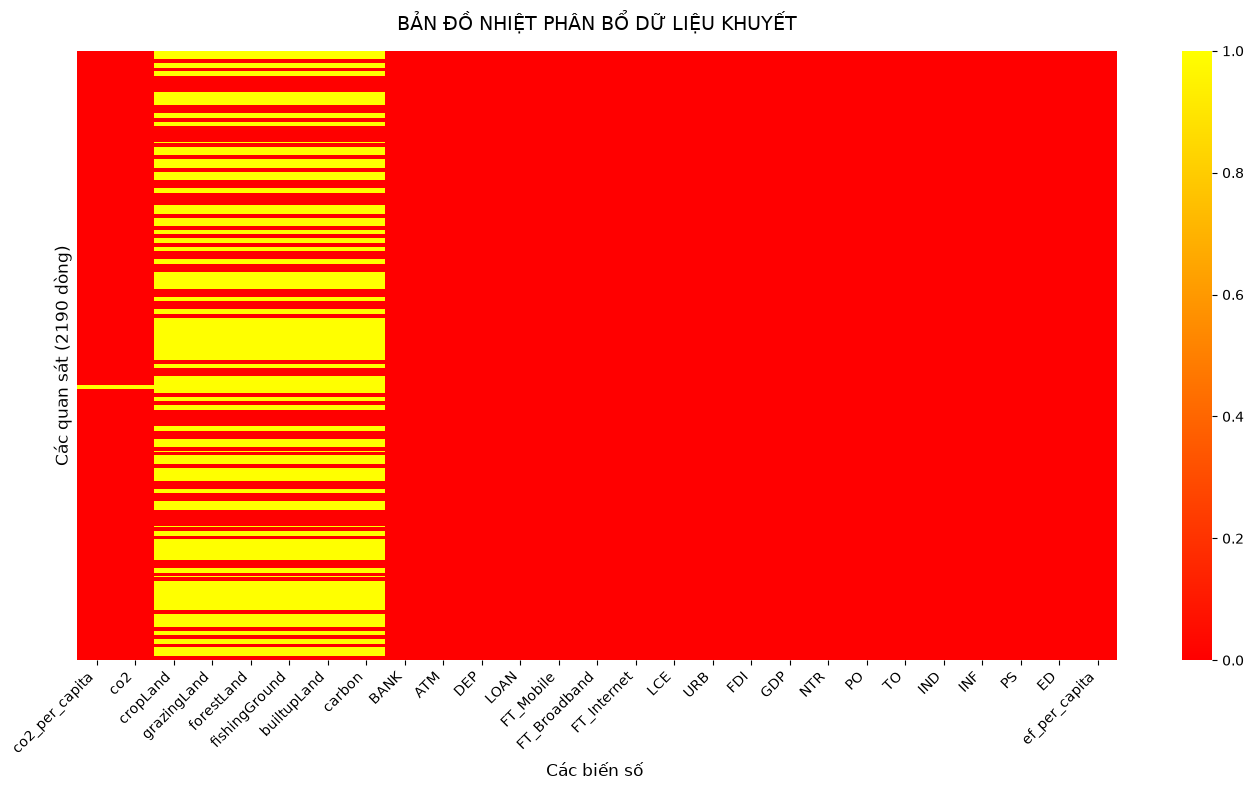

In [16]:
plt.figure(figsize=(14,8))

cols = [c for c in master_df.columns if c not in ['country_code', 'country', 'year']]

sns.heatmap(master_df[cols].isnull(), cbar=True, yticklabels=False, cmap='autumn')
plt.title('BẢN ĐỒ NHIỆT PHÂN BỔ DỮ LIỆU KHUYẾT', fontsize = 14, pad = 15)
plt.xlabel('Các biến số ',fontsize = 12 )
plt.ylabel(f'Các quan sát ({master_df.shape[0]} dòng)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
master_df.describe()

,year,co2_per_capita,co2,cropLand,grazingLand,forestLand,fishingGround,builtupLand,carbon,BANK,...,FDI,GDP,NTR,PO,TO,IND,INF,PS,ED,ef_per_capita
count,2190.000000,2175.000000,2175.000000,936.000000,936.000000,936.000000,936.000000,936.000000,936.000000,2190.000000,...,2190.000000,2190.000000,2190.000000,2.190000e+03,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,2017.000000,4.980094,230.846305,0.587826,0.290268,0.498043,0.132842,0.092263,1.703127,18.079582,...,8.335919,16837.206705,6.670893,4.742823e+07,93.250692,29.001546,129.018512,0.084988,26.509098,3.550924
std,4.321481,5.630083,999.887417,0.331559,0.519394,0.560937,0.158521,0.054787,1.679855,14.403005,...,57.870138,24172.132360,54.309016,1.643739e+08,56.750742,161.296418,4844.944460,0.940146,74.403249,2.198598
min,2010.000000,0.022000,0.007000,0.078431,0.003512,0.064365,0.000412,0.004143,0.050063,0.000000,...,-1303.108267,0.000000,0.000000,9.646000e+03,0.000000,0.000000,-28.760135,-2.750564,0.000000,0.272142
25%,2013.000000,0.995000,2.615500,0.335389,0.083081,0.174752,0.034510,0.053084,0.340110,7.616562,...,1.101034,2371.518208,0.182126,1.475092e+06,54.463989,18.162616,1.401297,-0.553486,0.480325,1.870438
50%,2017.000000,3.479000,18.294000,0.515876,0.183199,0.289549,0.074895,0.085161,1.275730,15.140115,...,2.782355,6711.161992,1.769427,8.739957e+06,81.981462,24.159669,3.664519,0.157931,4.386200,3.324784
75%,2021.000000,6.705500,100.626500,0.762904,0.356993,0.591815,0.184761,0.125493,2.665172,24.149340,...,5.433591,20842.578939,7.133421,3.512258e+07,116.248449,30.211544,7.291750,0.884736,22.106850,4.797306
max,2024.000000,33.961000,12289.037000,1.939317,5.067615,3.918504,1.159158,0.277943,12.599307,96.076150,...,1282.607229,247170.103807,2503.375306,1.450936e+09,526.451827,7521.032092,225652.234994,1.644869,572.269900,17.643144


<Axes: xlabel='year', ylabel='Median'>

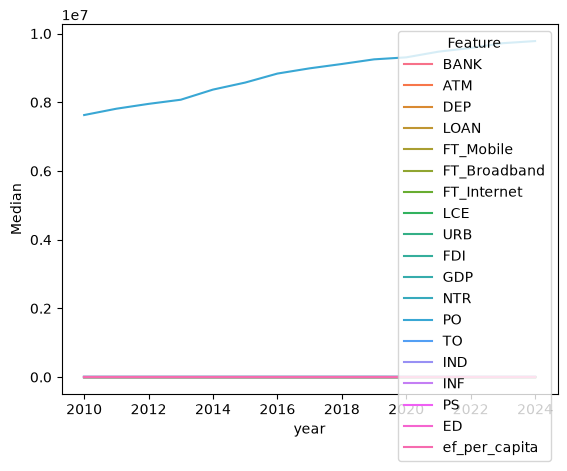

In [27]:
cols = ['country_code', 'year', 'BANK','ATM','DEP','LOAN','FT_Mobile','FT_Broadband','FT_Internet','LCE','URB','FDI','GDP','NTR','PO','TO','IND','INF','PS','ED','ef_per_capita']

# Define feature_cols explicitly (everything except country_code and year)
feature_cols = [col for col in cols if col not in ['country_code', 'year']]
plt.figsuz
c = master_df[cols]

# Group by year and calculate median for all numeric columns
# (country_code is safely dropped by pandas during median calculation)
line_df = c.groupby('year')[feature_cols].median().reset_index()

# Melt the dataframe (id_vars should only be 'year' now)
melted_df = line_df.melt(id_vars=['year'], value_vars=feature_cols, 
                         var_name='Feature', value_name='Median')

# Plot with Seaborn
sns.lineplot(data=melted_df, x='year', y='Median', hue='Feature')

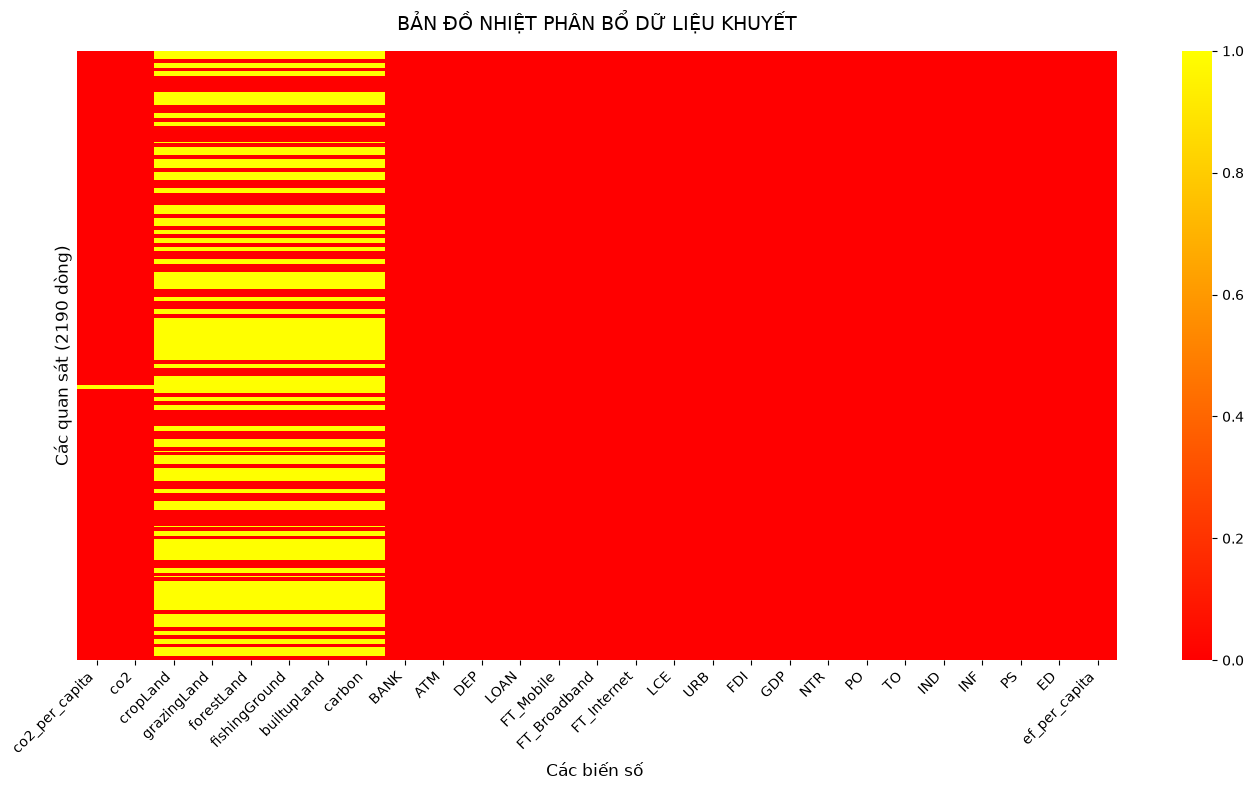

In [19]:
plt.figure(figsize=(14,8))

cols = [c for c in master_df.columns if c not in ['country_code', 'country', 'year']]

sns.heatmap(master_df[cols].isnull(), cbar=True, yticklabels=False, cmap='autumn')
plt.title('BẢN ĐỒ NHIỆT PHÂN BỔ DỮ LIỆU KHUYẾT', fontsize = 14, pad = 15)
plt.xlabel('Các biến số ',fontsize = 12 )
plt.ylabel(f'Các quan sát ({master_df.shape[0]} dòng)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
country_type = {
    "High-Income": [
        "Antigua and Barbuda", "Andorra", "Australia", "Austria", "Bahrain", 
        "Belgium", "Brunei", "Canada", "Chile", "Croatia", "Cyprus", 
        "Czech Republic", "Czechia", "Denmark", "Estonia", "Finland", 
        "France", "Germany", "Greece", "Hungary", "Iceland", "Ireland", 
        "Israel", "Italy", "Japan", "Kuwait", "Liechtenstein", "Lithuania", 
        "Luxembourg", "Malta", "Monaco", "Netherlands", "New Zealand", 
        "Norway", "Oman", "Panama", "Poland", "Portugal", "Romania", 
        "Saint Kitts and Nevis", "Saudi Arabia", "Seychelles", "Singapore", 
        "Slovakia", "Slovenia", "South Korea", "Spain", "Sweden", 
        "Switzerland", "Trinidad and Tobago", "United Arab Emirates", 
        "United Kingdom", "United States", "Uruguay"
    ],
    "Upper-Middle-Income": [
        "Argentina", "Armenia", "Belize", "Brazil", "Bulgaria", 
        "China", "Colombia", "Costa Rica", "Dominica", "Dominican Republic", 
        "Ecuador", "Fiji", "Gabon", "Georgia", "Jamaica", "Kazakhstan", 
        "Malaysia", "Marshall Islands", "Mauritius", "Mexico", "Montenegro", 
        "Palau", "Peru", "Russia", "Samoa", "South Africa", "Suriname", 
        "Thailand", "Turkey", "Venezuela"
    ],
    "Lower-Middle-Income": [
        "Bangladesh", "Bhutan", "Cape Verde", "Cambodia", "Comoros", 
        "Djibouti", "Ghana", "Honduras", "India", "Indonesia", "Iran", 
        "Iraq", "Jordan", "Kenya", "Kiribati", "Kyrgyzstan", "Laos", 
        "Lebanon", "Lesotho", "Micronesia", "Micronesia (country)", 
        "Mongolia", "Morocco", "Myanmar", "Nepal", "Nigeria", "Pakistan", 
        "Papua New Guinea", "Philippines", "Sao Tome and Principe", 
        "Solomon Islands", "Sri Lanka", "East Timor", "Tunisia", 
        "Ukraine", "Uzbekistan", "Vanuatu", "Zambia"
    ],
    "Low-Income": [
        "Burkina Faso", "Central African Republic", "Ethiopia", 
        "Gambia", "Haiti", "Liberia", "Malawi", "Mali", "Mozambique", 
        "Mauritania", "Namibia", "Niger", "Rwanda", "Togo", "Tonga", 
        "Tuvalu", "Uganda", "Yemen"
    ]
 }

# Hàm ánh xạ quốc gia sang nhóm thu nhập
def get_income_group(country_name):
    for income_group, countries in country_type.items():
        if country_name in countries:
            return income_group
    return "Unknown"  # Trường hợp quốc gia không nằm trong danh sách

# Tạo cột mới trong master_df
master_df['income_group'] = master_df['country'].apply(get_income_group)
# Sau đó bạn có thể groupby thoải mái

master_df['GDP'] = master_df['GDP'].fillna(
    master_df.groupby(['year', 'income_group'])['GDP'].transform('median')
)

display(master_df)

,country_code,country,year,co2_per_capita,co2,cropLand,grazingLand,forestLand,fishingGround,builtupLand,...,GDP,NTR,PO,TO,IND,INF,PS,ED,ef_per_capita,income_group
0,AND,Andorra,2010,6.400,0.517,NaN,NaN,NaN,NaN,NaN,...,36277.264443,0.000000,80706.0,111.703057,13.125646,0.374314,1.333205,15.724656,5.487904,High-Income
1,AND,Andorra,2011,6.311,0.491,NaN,NaN,NaN,NaN,NaN,...,37637.486834,0.000000,77783.0,111.320200,11.908853,0.196764,1.325841,15.920919,5.561615,High-Income
2,AND,Andorra,2012,6.340,0.487,NaN,NaN,NaN,NaN,NaN,...,36206.978436,0.000000,76834.0,107.814550,11.071580,0.174557,1.325064,16.018362,5.491126,High-Income
3,AND,Andorra,2013,6.332,0.476,NaN,NaN,NaN,NaN,NaN,...,35684.169435,0.000000,75194.0,105.612260,10.618247,0.448492,1.322689,16.079146,5.471455,High-Income
4,AND,Andorra,2014,6.259,0.462,NaN,NaN,NaN,NaN,NaN,...,37300.624420,0.000000,73737.0,106.118048,10.153531,-0.084019,1.330893,16.195594,5.576045,High-Income
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,ZMB,Zambia,2020,0.524,9.991,0.235469,0.111598,0.571829,0.037087,0.022368,...,1228.735001,16.222231,19059395.0,79.206849,40.197690,13.913871,-0.367936,5.133000,1.210655,Lower-Middle-Income
2186,ZMB,Zambia,2021,0.477,9.350,0.210848,0.112597,0.555470,0.039822,0.024054,...,1269.108218,35.264148,19603607.0,86.208511,41.831938,25.142778,-0.158277,5.526800,1.196523,Lower-Middle-Income
2187,ZMB,Zambia,2022,0.543,10.939,0.174024,0.135544,0.542246,0.041857,0.021983,...,1298.848050,14.321616,20152938.0,69.297315,35.283821,6.140318,0.045633,6.189700,1.195611,Lower-Middle-Income
2188,ZMB,Zambia,2023,0.571,11.831,0.175120,0.112446,0.526382,0.044814,0.025890,...,1330.859982,13.850478,20723965.0,78.241887,35.107778,7.094630,-0.011146,6.171900,1.167346,Lower-Middle-Income


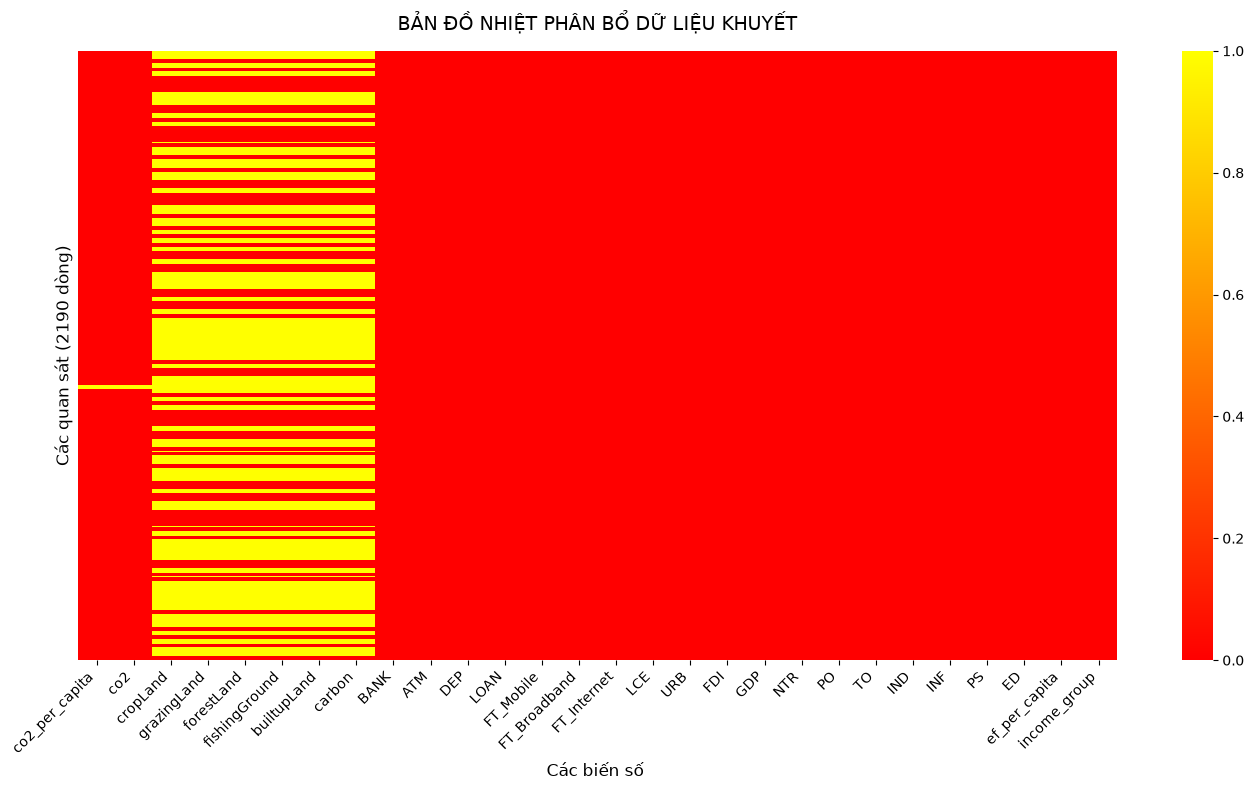

In [21]:
plt.figure(figsize=(14,8))

cols = [c for c in master_df.columns if c not in ['country_code', 'country', 'year']]

sns.heatmap(master_df[cols].isnull(), cbar=True, yticklabels=False, cmap='autumn')
plt.title('BẢN ĐỒ NHIỆT PHÂN BỔ DỮ LIỆU KHUYẾT', fontsize = 14, pad = 15)
plt.xlabel('Các biến số ',fontsize = 12 )
plt.ylabel(f'Các quan sát ({master_df.shape[0]} dòng)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()